# Combine Raw Data Files

Notebook here will combine several dataframes into a single dataframe. Dataframes are created from transformed raw data files, now in the form of csv files.

In [43]:
import pandas as pd
import os
import re

In [ ]:
systems = ['GRA','PWAVE-L', 'MS', 'NGR', 'RSC', 'MSPOINT', 'RGB', 'SRM', 'DSC']

path = "C:/SOD_OUTPUT/"


for system in systems:
    
    print(system)
    search_path = os.path.join(path,system)
    print(search_path)
    # set the regex pattern to filter out files
    
    pat = rf'.+{re.escape(system)}_instrument_file_.+$'
    print(pat)
    os.listdir(search_path)
    all_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            all_files.append(os.path.normpath(os.path.join(root, file)))

    files = [f for f in all_files if re.match(pat,f)]


    # Combine all CSV files in the 'files' list into a single DataFrame
    # Values are sorted by sample hierarchy.
    df_combined = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    df = df_combined.sort_values(by=['expedition','site','hole', 'core', 'section', 'sect_half', 'depth_csfa_m'])

    outpath = search_path + "/compilation.csv"
    print(outpath)
    df.to_csv(outpath, index=False)

GRA
C:/SOD_OUTPUT/GRA
.+GRA_instrument_file_.+$
['C:\\SOD_OUTPUT\\GRA\\402-U1612A-10R-1_20240215215847\\GRA_instrument_file_402-U1612A-10R-1_20240215215847.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-10R-2_20240215220912\\GRA_instrument_file_402-U1612A-10R-2_20240215220912.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-10R-3_20240215222448\\GRA_instrument_file_402-U1612A-10R-3_20240215222448.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-10R-4_20240215223438\\GRA_instrument_file_402-U1612A-10R-4_20240215223438.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-13R-1_20240216030315\\GRA_instrument_file_402-U1612A-13R-1_20240216030315.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-13R-2_20240216031131\\GRA_instrument_file_402-U1612A-13R-2_20240216031131.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-13R-CC_20240216031713\\GRA_instrument_file_402-U1612A-13R-CC_20240216031713.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-16R-1_20240216071758\\GRA_instrument_file_402-U1612A-16R-1_20240216071758.csv', 'C:\\SOD_OUTPUT\\GRA\\402-U1612A-16R-2_202402

,datetime,labelid,user,text_id,instrument,instrument_group,observed_length,comment,period,archive,...,relative_error,absolute_error,depth_csfa_m,expedition,site,hole,core,core_type,section,sect_half
605,2024-02-15 13:19:54 UTC,402-U1612A-3R-1,KOWALSKI,SECT13015321,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.44,NaN,300.0,c:\aux_data\zip\u1612a\402-u1612a-3r-1_sect130...,...,0.059476,2.165576,17.9,402,U1612,A,3,R,1,NaN
606,2024-02-15 13:19:54 UTC,402-U1612A-3R-1,KOWALSKI,SECT13015321,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.44,NaN,300.0,c:\aux_data\zip\u1612a\402-u1612a-3r-1_sect130...,...,0.020066,0.830259,18.0,402,U1612,A,3,R,1,NaN
607,2024-02-15 13:19:54 UTC,402-U1612A-3R-1,KOWALSKI,SECT13015321,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.44,NaN,300.0,c:\aux_data\zip\u1612a\402-u1612a-3r-1_sect130...,...,0.009339,0.404526,18.1,402,U1612,A,3,R,1,NaN
608,2024-02-15 13:19:54 UTC,402-U1612A-3R-1,KOWALSKI,SECT13015321,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.44,NaN,300.0,c:\aux_data\zip\u1612a\402-u1612a-3r-1_sect130...,...,0.009169,0.410457,18.2,402,U1612,A,3,R,1,NaN
609,2024-02-15 13:19:54 UTC,402-U1612A-3R-1,KOWALSKI,SECT13015321,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.44,NaN,300.0,c:\aux_data\zip\u1612a\402-u1612a-3r-1_sect130...,...,0.009164,0.409664,18.3,402,U1612,A,3,R,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,2024-04-07 11:31:53 UTC,402-U1612B-4R-1,KOWALSKI,SECT13152541,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.51,NaN,300.0,c:\aux_data\zip\u1612b\402-u1612b-4r-1_sect131...,...,0.006391,0.555400,326.2,402,U1612,B,4,R,1,NaN
770,2024-04-07 11:31:53 UTC,402-U1612B-4R-1,KOWALSKI,SECT13152541,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.51,NaN,300.0,c:\aux_data\zip\u1612b\402-u1612b-4r-1_sect131...,...,0.006438,0.542293,326.3,402,U1612,B,4,R,1,NaN
771,2024-04-07 11:31:53 UTC,402-U1612B-4R-1,KOWALSKI,SECT13152541,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.51,NaN,300.0,c:\aux_data\zip\u1612b\402-u1612b-4r-1_sect131...,...,0.007180,0.491329,326.4,402,U1612,B,4,R,1,NaN
772,2024-04-07 11:31:53 UTC,402-U1612B-4R-1,KOWALSKI,SECT13152541,"0) ORTEC MODEL: ASPEC927 S/N: 7022362, 1) ORTE...",NGR SYSTEM,1.51,NaN,300.0,c:\aux_data\zip\u1612b\402-u1612b-4r-1_sect131...,...,0.021120,1.136097,326.5,402,U1612,B,4,R,1,NaN


In [ ]:


df.to_csv()

In [57]:
import numpy as np

C:\Users\vpercuoco\AppData\Local\Temp\ipykernel_28740\4268203818.py:1: FutureWarning: The provided callable <function mean at 0x000001C651987EC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby(by=['detector'])['relative_error'].agg([np.mean, np.std]).plot()
C:\Users\vpercuoco\AppData\Local\Temp\ipykernel_28740\4268203818.py:1: FutureWarning: The provided callable <function std at 0x000001C651990040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df.groupby(by=['detector'])['relative_error'].agg([np.mean, np.std]).plot()


<Axes: xlabel='detector'>

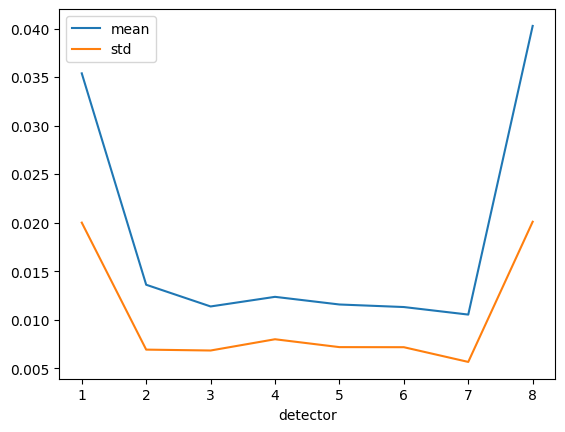

In [59]:
df.groupby(by=['detector'])['relative_error'].agg([np.mean, np.std]).plot()

In [50]:
import matplotlib.pyplot as plt

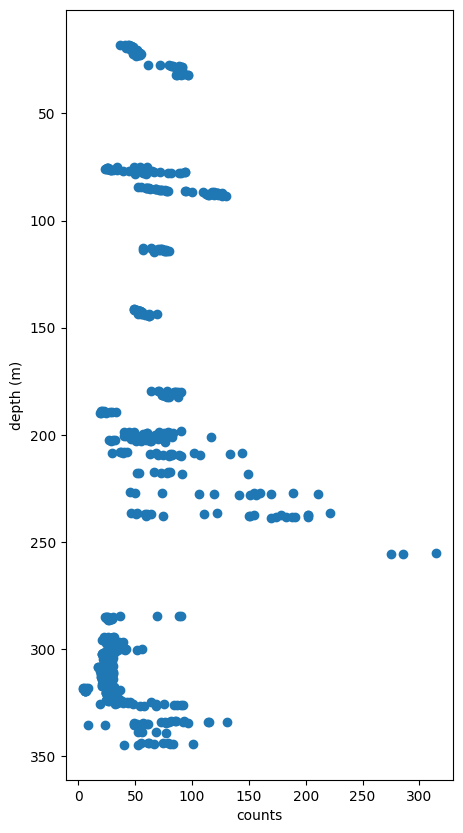

In [56]:
fig, ax = plt.subplots(1,1,figsize=(5,10))

ax.scatter(df['total_counts_per_sec'], y=df['depth_csfa_m'])
ax.invert_yaxis()
#df.plot(x='total_counts_per_sec', y='depth_csfa_m', kind='scatter')
ax.set_xlabel('counts')
ax.set_ylabel('depth (m)')
plt.show()